In [1]:

import numpy as np

class HopfieldNetwork:
    def __init__(self, n):
        self.n = n
        self.weights = np.zeros((n, n))

    def train(self, patterns):
        for pattern in patterns:
            pattern = np.reshape(pattern, (self.n, 1))
            self.weights += np.dot(pattern, pattern.T)
        np.fill_diagonal(self.weights, 0)

    def predict(self, pattern, max_iter=100):
        pattern = np.reshape(pattern, (self.n, 1))
        for _ in range(max_iter):
            new_pattern = np.sign(np.dot(self.weights, pattern))
            if np.array_equal(pattern, new_pattern):
                return np.squeeze(new_pattern)
            pattern = new_pattern
        return np.squeeze(pattern)

network = HopfieldNetwork(4)
patterns = [[1, -1, 1, -1], [-1, 1, -1, 1],[1,-1,-1,1],[-1,1,1,1]]
network.train(patterns)
corrupted_pattern = [1, -1, -1, -1]
predicted_pattern = network.predict(corrupted_pattern)
print("Corrupted pattern:", corrupted_pattern)
print("Predicted pattern:", predicted_pattern)


Corrupted pattern: [1, -1, -1, -1]
Predicted pattern: [ 1. -1.  1. -1.]


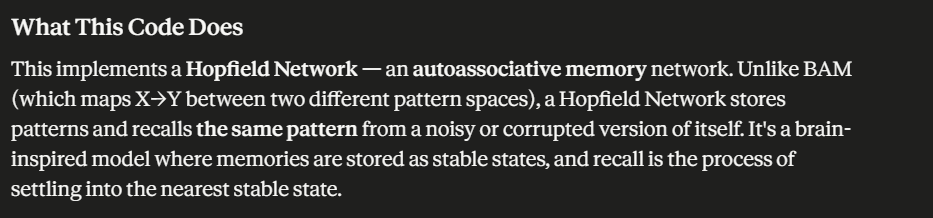

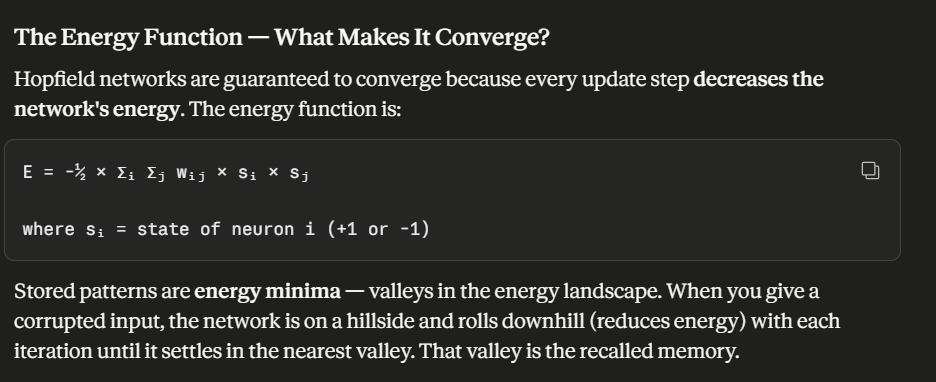